<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml20_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RNN(Recurrent Neural Network, 순환 신경망)

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

# IMDB 데이터셋

*   imdb.com 사이트 사용자들의 영화 리뷰를 긍정(1), 부정(0)으로 분류한 데이터.
*   25,000개 훈련 샘플(영화 리뷰)와 25,000개의 테스트 샘플(영화 리뷰).
*   샘플들마다 사용된 단어(토큰, token) 개수가 다름.
    *   샘플들마다 특성(feature)의 개수가 다름 --> 전처리가 필요.
*   Keras datasets에서 다운로드한 데이터는 (영어) 단어들이 숫자로 인코딩된 상태.
    *   단어-숫자 dict
*   (참고) KoNLP 라이브러리 - 한국어 자연어 처리 라이브러리.

In [62]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=500)
# num_words=500: 가장 자주 사용된 500개의 단어만 인코딩. 그 이외의 단어들은 같은 숫자(500개 이외의 단어)로 인코딩.
# num_words=None: 기본값. 단어 사전에 포함된 모든 단어들을 인코딩.

In [63]:
x_train.shape  #> (25000,) 모양의 1차원 배열 - 25,000개의 영화 리뷰들.

(25000,)

In [64]:
x_test.shape

(25000,)

In [65]:
y_train.shape

(25000,)

In [66]:
np.unique(y_train, return_counts=True)  #> 훈련 레이블: 부정(0)/긍정(1) 리뷰는 같은 비율.

(array([0, 1]), array([12500, 12500]))

In [67]:
np.unique(y_test, return_counts=True)

(array([0, 1]), array([12500, 12500]))

## 훈련 셋 탐색

In [68]:
print(x_train[0])  # 첫번째 훈련 샘플(영화 리뷰)

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [69]:
print(type(x_train[0]))  #> list

<class 'list'>


In [70]:
len(x_train[0])  #> 첫번째 훈련 샘플의 길이(영화 리뷰에서 사용된 단어 개수)

218

In [71]:
print(x_train[1])  # 두번째 훈련 샘플(영화 리뷰)

[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 2, 8, 118, 2, 14, 394, 20, 13, 119, 2, 189, 102, 5, 207, 110, 2, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2, 2, 5, 2, 4, 116, 9, 35, 2, 4, 229, 9, 340, 2, 4, 118, 9, 4, 130, 2, 19, 4, 2, 5, 89, 29, 2, 46, 37, 4, 455, 9, 45, 43, 38, 2, 2, 398, 4, 2, 26, 2, 5, 163, 11, 2, 2, 4, 2, 9, 194, 2, 7, 2, 2, 349, 2, 148, 2, 2, 2, 15, 123, 125, 68, 2, 2, 15, 349, 165, 2, 98, 5, 4, 228, 9, 43, 2, 2, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 2, 228, 2, 5, 2, 2, 245, 2, 5, 4, 2, 131, 152, 491, 18, 2, 32, 2, 2, 14, 9, 6, 371, 78, 22, 2, 64, 2, 9, 8, 168, 145, 23, 4, 2, 15, 16, 4, 2, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]


In [72]:
len(x_train[1])

189

imdb 데이터셋(x_train, x_test)은 파이썬 list 객체들을 원소로 갖는 **1차원 ndarray**.

각각의 리스트들은 정수들을 저장하고 있음. 정수들은 영화 리뷰에서 사용된 단어(토큰)을 의미함.

각각의 리스트들은 길이가 다름. -> 2차원 ndarray로 만들 수 없음.

In [73]:
for i in range(5):
    print(f'인덱스 {i}: 토큰 개수 = {len(x_train[i])}')

인덱스 0: 토큰 개수 = 218
인덱스 1: 토큰 개수 = 189
인덱스 2: 토큰 개수 = 141
인덱스 3: 토큰 개수 = 550
인덱스 4: 토큰 개수 = 147


In [74]:
for i in range(5):
    print(x_train[i][:30])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480]
[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 2, 8, 118, 2, 14, 394, 20, 13, 119, 2, 189, 102, 5, 207, 110]
[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 2, 54, 61, 369, 13, 71, 149, 14, 22, 112, 4, 2, 311, 12, 16, 2, 33, 75]
[1, 4, 2, 2, 33, 2, 4, 2, 432, 111, 153, 103, 4, 2, 13, 70, 131, 67, 11, 61, 2, 2, 35, 2, 2, 61, 2, 452, 2, 4]
[1, 249, 2, 7, 61, 113, 10, 10, 13, 2, 14, 20, 56, 33, 2, 18, 457, 88, 13, 2, 2, 45, 2, 13, 70, 79, 49, 2, 2, 13]


모든 리스트는 숫자 1로 시작. 숫자 1의 의미는 리뷰의 시작을 의미.

## 단어 인덱스(word index)

In [75]:
word_index = keras.datasets.imdb.get_word_index()

In [76]:
print(type(word_index))

<class 'dict'>


In [77]:
len(word_index)  # 88,584개의 단어-인덱스 구성된 dict

88584

In [78]:
for i, (k, v) in enumerate(word_index.items()):
    print(k, ':', v)
    if i == 9:
        break  # 앞에서 10개 아이템들만 출력하고 끝냄

fawn : 34701
tsukino : 52006
nunnery : 52007
sonja : 16816
vani : 63951
woods : 1408
spiders : 16115
hanging : 2345
woody : 2289
trawling : 52008


`get_word_index()` 함수:

*   (word, index) 쌍으로 이루어진 아이템들을 저장한 dict를 리턴.
*   단어와 그 단어에 해당하는 숫자(인덱스)를 갖음.
*   숫자(인덱스)가 작을 수록 빈도수가 높음. 숫자가 클 수록 자주 사용되지 않는 단어.
*   영화 리뷰의 단어들을 숫자로 인코딩할 때 사용.


In [79]:
word_index.get('the')

1

In [80]:
# dict.items(): [(key1, value1), (key2, value2), ...]
# word_index 딕셔너리를 인덱스(value) 오름차순으로 정렬해서 출력.
sorted_word_index = sorted(word_index.items(), key=lambda x: x[1])
sorted_word_index[:10]  # 단어 인덱스가 작은 순서로 앞에서 10개 출력

[('the', 1),
 ('and', 2),
 ('a', 3),
 ('of', 4),
 ('to', 5),
 ('is', 6),
 ('br', 7),
 ('in', 8),
 ('it', 9),
 ('i', 10)]

word_index 딕셔너리를 인덱스를 키(key)로 하고, 단어를 값(value)로 하는 딕셔너리로 변환.

*   0: padding(패딩)
*   1: 문장의 시작
*   2: 자주 사용되는 단어 n(=500)개에 포함되지 않는 단어들.


In [81]:
start_index = 1  # 문장 시작
oov_index = 2  # oov(out of value). n개의 어휘 사전에 없는 단어.
idx_from = 3
index_word = {(v + idx_from): k for k, v in word_index.items()}
index_word[start_index] = '[START]'
index_word[oov_index] = '[OOV]'

In [82]:
for i in range(1, 11):
    print(i, ':', index_word.get(i))

1 : [START]
2 : [OOV]
3 : None
4 : the
5 : and
6 : a
7 : of
8 : to
9 : is
10 : br


In [83]:
# 샘플(훈련셋, 테스트셋)의 인코딩된 숫자들을 단어로 변환
def decode_review(sample):
    # sample: 숫자들을 저장하는 리스트(list)
    return ' '.join([index_word.get(i) for i in sample])

In [84]:
decode_review(x_train[0])

"[START] this film was just [OOV] [OOV] [OOV] [OOV] story direction [OOV] really [OOV] the part they played and you could just [OOV] being there [OOV] [OOV] is an amazing actor and now the same being director [OOV] father came from the same [OOV] [OOV] as [OOV] so i loved the fact there was a real [OOV] with this film the [OOV] [OOV] throughout the film were great it was just [OOV] so much that i [OOV] the film as [OOV] as it was [OOV] for [OOV] and would recommend it to everyone to watch and the [OOV] [OOV] was amazing really [OOV] at the end it was so [OOV] and you know what they say if you [OOV] at a film it must have been good and this definitely was also [OOV] to the two little [OOV] that played the [OOV] of [OOV] and [OOV] they were just [OOV] children are often left out of the [OOV] [OOV] i think because the stars that play them all [OOV] up are such a big [OOV] for the whole film but these children are amazing and should be [OOV] for what they have done don't you think the whol

In [85]:
decode_review(x_train[1])

"[START] big [OOV] big [OOV] bad music and a [OOV] [OOV] [OOV] these are the [OOV] to best [OOV] this terrible movie i love [OOV] horror movies and i've seen [OOV] but this had got to be on of the worst ever made the plot is [OOV] [OOV] and [OOV] the acting is an [OOV] the script is completely [OOV] the best is the end [OOV] with the [OOV] and how he [OOV] out who the killer is it's just so [OOV] [OOV] written the [OOV] are [OOV] and funny in [OOV] [OOV] the [OOV] is big [OOV] of [OOV] [OOV] men [OOV] those [OOV] [OOV] [OOV] that show off their [OOV] [OOV] that men actually [OOV] them and the music is just [OOV] [OOV] that plays over and over again in almost every scene there is [OOV] music [OOV] and [OOV] [OOV] away [OOV] and the [OOV] still doesn't close for [OOV] all [OOV] [OOV] this is a truly bad film [OOV] only [OOV] is to look back on the [OOV] that was the [OOV] and have a good old laugh at how bad everything was back then"

## 각 샘플(영화 리뷰)의 길이 분포

In [87]:
review_lengths = pd.Series(data=[len(x) for x in x_train])

In [88]:
review_lengths.describe()

,0
count,25000.000000
mean,238.713640
std,176.497204
min,11.000000
25%,130.000000
50%,178.000000
75%,291.000000
max,2494.000000


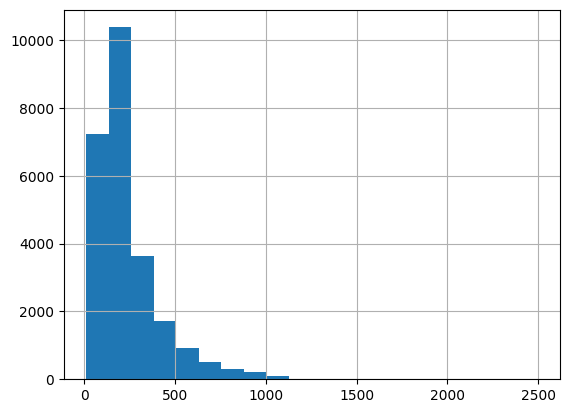

In [90]:
review_lengths.hist(bins=20)
plt.show()

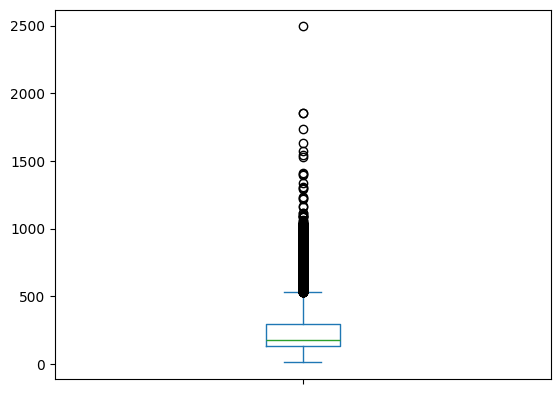

In [91]:
review_lengths.plot.box()
plt.show()

영화 리뷰에서 사용된 단어 개수의 평균은 238개, 중앙값은 178개.

리뷰에서 사용된 단어 개수가 매우 많은 리뷰 몇 개들(outliers)이 평균을 높임.

대부분의 영화 사용자 리뷰에서 사용된 단어 개수는 300개 미만.

영화 리뷰 샘플마다 100개의 단어(토큰)만 사용.

길이가 100 이상인 샘플들은 잘라내고, 길이가 100 미만인 샘플들은 0을 채움(패딩).
--> (25_000,) 모양의 훈련/테스트 셋을 (25_000, 100) 모양의 2차원 배열로 변환.

## Data Wrangling

`keras.preprocessing.sequence.pad_sequences()` 함수의 파라미터:

*   `sequences`: 변환할 데이터(훈련/테스트 셋)
*   `maxlen`: 각 샘플의 최대 길이.
*   `padding`: 샘플의 길이가 `maxlen`보다 짧을 때 패딩을 넣는 위치. 기본값은 'pre'. 패딩값(0)을 시퀀스의 앞에 채우는 동작이 기본값.
*   `truncate`: 샘플의 길이가 `maxlen`보다 길 때 샘플을 자르는 위치. 기본값은 'pre'. 시퀀스의 앞쪽을 자르는 동작이 기본값.
*   순환신경망을 사용할 때 `padding`과 `truncate`는 모두 'pre' 방식을 선호.


In [92]:
x_train_seq = keras.preprocessing.sequence.pad_sequences(sequences=x_train, maxlen=100)

In [93]:
x_test_seq = keras.preprocessing.sequence.pad_sequences(sequences=x_test, maxlen=100)

In [94]:
x_train_seq.shape  # (n_samples, n_features)

(25000, 100)

In [95]:
x_test_seq.shape

(25000, 100)

In [97]:
for i in range(3):
    print(x_train_seq[i])

[  2  33   6  22  12 215  28  77  52   5  14 407  16  82   2   8   4 107
 117   2  15 256   4   2   7   2   5   2  36  71  43   2 476  26 400 317
  46   7   4   2   2  13 104  88   4 381  15 297  98  32   2  56  26 141
   6 194   2  18   4 226  22  21 134 476  26 480   5 144  30   2  18  51
  36  28 224  92  25 104   4 226  65  16  38   2  88  12  16 283   5  16
   2 113 103  32  15  16   2  19 178  32]
[163  11   2   2   4   2   9 194   2   7   2   2 349   2 148   2   2   2
  15 123 125  68   2   2  15 349 165   2  98   5   4 228   9  43   2   2
  15 299 120   5 120 174  11 220 175 136  50   9   2 228   2   5   2   2
 245   2   5   4   2 131 152 491  18   2  32   2   2  14   9   6 371  78
  22   2  64   2   9   8 168 145  23   4   2  15  16   4   2   5  28   6
  52 154 462  33  89  78 285  16 145  95]
[  2   4   2  33  89  78  12  66  16   4 360   7   4  58 316 334  11   4
   2  43   2   2   8 257  85   2  42   2   2  83  68   2  15  36 165   2
 278  36  69   2   2   8 106  14   2   2

In [98]:
for i in range(25_000):
    if x_train_seq[i, 0] == 0:
        print(x_train_seq[i])
        break

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   1   2 128  74  12   2 163  15   4   2   2   2   2  32  85
 156  45  40 148 139 121   2   2  10  10   2 173   4   2   2  16   2   8
   4 226  65  12  43 127  24   2  10  10]


*   FFNN(Feed-Forward Neural Network): 데이터의 흐름이 앞으로만 전달되는 신경망
    *   완전연결 신경망
    *   합성곱 신경망(CNN)
*   RNN(Recurrent Neural Network): 순환 신경망
    *   순차 데이터(sequential data): 순환 신경망에서 사용하는 데이터. 텍스트(문장) 또는 시계열 데이터처럼 순서가 중요한 데이터.
    *   타임 스텝(time step): 샘플을 처리하는 한 단계. 시퀀스의 각 원소들을 순서대로 처리하는 단계.
    *   셀(cell): 순환 신경망 층(recurrent layer)의 유닛(뉴런).
        *   Dense에서 unit, Conv2D에서 filter와 비슷한 개념.
    *   은닉 상태(hidden state): 셀의 출력
    *   시퀀스(sequence): 순환 신경망에서 사용하는 하나의 샘플.
    *   자연어 처리(NLP, Natural Language Processing)와 같은 경우, 단어들을 숫자로 인코딩을 함. 인코딩된 숫자의 크기는 중요한 게 아님. 인코딩된 정수가 신경망으로 직접 주입되면 안됨.
        *   One-Hot Encoding
            *   단점: 계산량이 많아지고 메모리를 많이 사용하게 됨.
            *   CategoryEncoding 클래스를 이용.
        *   Word-Embedding
            *   One-Hot encoding의 단점을 보완.
            *   정수 1개를 몇 개의 실수들의 벡터로 인코딩.
            *   Embedding 클래스를 이용.

# One-Hot Encoding을 사용한 RNN

*   시퀀스로 변환된 훈련셋을 훈련/검증 셋으로 나눔.
*   신경망의 첫번째 층을 CategoryEncoding 클래스를 사용(One-Hot Encoding 사용).
*   SimpleRNN을 두번째 층으로 설정
*   출력층(Dense)을 연결.

In [99]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train_seq, y_train,
                                            test_size=0.2,
                                            stratify=y_train,
                                            random_state=42)

In [100]:
x_tr.shape  # (n_samples, n_features)

(20000, 100)

In [101]:
x_val.shape

(5000, 100)

In [102]:
np.unique(y_tr, return_counts=True)

(array([0, 1]), array([10000, 10000]))

In [103]:
keras.utils.set_random_seed(42)  # Python, NumPy, TensforFlow 난수 씨드 설정

In [104]:
rnn_1 = keras.Sequential(layers=[
    keras.layers.Input(shape=(100,)),
    keras.layers.CategoryEncoding(num_tokens=500, output_mode='one_hot'),
    keras.layers.SimpleRNN(units=8),
    keras.layers.Dense(units=1, activation='sigmoid')
])

In [105]:
rnn_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ category_encoding               │ (None, 100, 500)       │             0 │
│ (CategoryEncoding)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

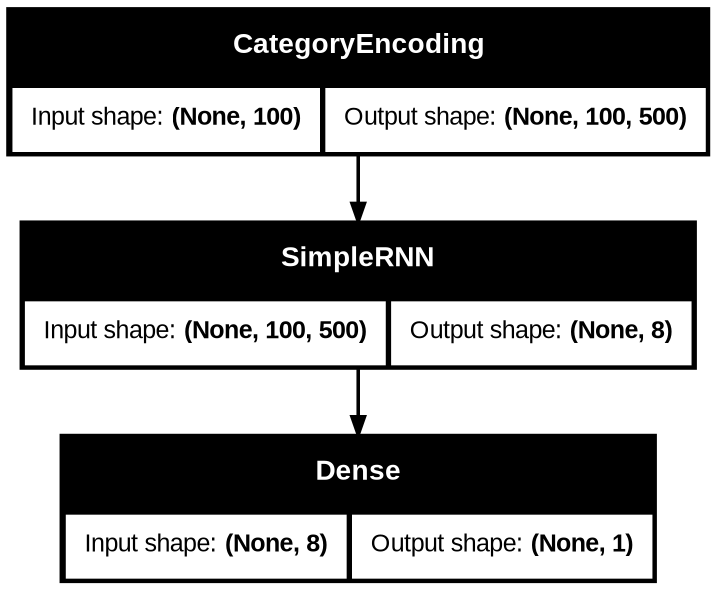

In [106]:
keras.utils.plot_model(model=rnn_1, dpi=128, show_shapes=True)

In [107]:
rnn_1.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.binary_crossentropy,
              metrics=[keras.metrics.binary_accuracy])

In [108]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath='rnn_1.keras', save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [109]:
result = rnn_1.fit(x=x_tr, y=y_tr, batch_size=64, epochs=1_000,
                   validation_data=[x_val, y_val],
                   callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - binary_accuracy: 0.5302 - loss: 0.6901 - val_binary_accuracy: 0.5816 - val_loss: 0.6771
Epoch 2/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - binary_accuracy: 0.6741 - loss: 0.6100 - val_binary_accuracy: 0.7044 - val_loss: 0.5687
Epoch 3/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - binary_accuracy: 0.7667 - loss: 0.4947 - val_binary_accuracy: 0.7554 - val_loss: 0.5133
Epoch 4/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - binary_accuracy: 0.7891 - loss: 0.4592 - val_binary_accuracy: 0.7512 - val_loss: 0.5263
Epoch 5/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - binary_accuracy: 0.8024 - loss: 0.4435 - val_binary_accuracy: 0.7634 - val_loss: 0.5133
Epoch 6/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - binary_accuracy: 0.8070 - loss: 0.4341 - val_binary_accuracy: 0.7568 - val_loss: 0.5370
Epoch 7/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - binary_accuracy: 0.8119 - loss: 0.4260 - val_binary_accuracy: 0.777